In [2]:
# Script R para transformar o banco IPDM e calcular a coluna media
# Ajustado para a estrutura de pastas do projeto:
# - Leitura: data/raw/Datasets_IPDM/dados_ipdm.csv
# - Escrita: data/processed/Datasets_IPDM/dados_ipdm_largura.csv

parse_numeric <- function(x) {
  x <- trimws(as.character(x))
  x <- gsub("\\.", "", x, fixed = TRUE)
  x <- gsub(",", ".", x, fixed = TRUE)
  as.numeric(x)
}

# Caminhos relativos (a partir da raiz do projeto ou da pasta do script)
# Se o script estiver em scripts/pesquisa_IPDM/, suba duas pastas para chegar na raiz
caminho_raw <- file.path("..", "..", "data", "raw", "Datasets_IPDM", "dados_ipdm.csv")
caminho_processed <- file.path("..", "..", "data", "processed", "Datasets_IPDM", "dados_ipdm_largura.csv")

# Leitura do CSV
base <- read.csv2(
  caminho_raw,
  sep = ";",
  dec = ",",
  stringsAsFactors = FALSE,
  check.names = FALSE,
  fileEncoding = "latin1"
)

# Padroniza colunas (verificando se existem para evitar erro)
if ("Municipio" %in% names(base)) names(base)[names(base) == "Municipio"] <- "municipio"
if ("Ano" %in% names(base)) names(base)[names(base) == "Ano"] <- "ano"
if ("Tipo" %in% names(base)) names(base)[names(base) == "Tipo"] <- "tipo"

base$municipio <- trimws(base$municipio)
base$tipo <- trimws(base$tipo)
base$ano <- as.integer(base$ano)
base$Valor <- parse_numeric(base$Valor)
base$`Valor Estado` <- parse_numeric(base$`Valor Estado`)

# Normaliza os nomes dos indicadores
base$tipo <- ifelse(base$tipo == "Riqueza", "riqueza",
  ifelse(base$tipo == "Longevidade", "longevidade",
    ifelse(base$tipo == "Escolaridade", "escolaridade",
      ifelse(base$tipo == "IPDM", "IPDM", base$tipo))))

# Remove duplicatas
base <- base[!duplicated(base[, c("cod_ibge", "municipio", "ano", "tipo")]), ]

# Cria tabelas separadas para cidade e estado
cidade <- split(base[, c("cod_ibge", "municipio", "ano", "tipo", "Valor")], base$tipo)
estado <- split(base[, c("cod_ibge", "municipio", "ano", "tipo", "Valor Estado")], base$tipo)

# Função auxiliar para wide
to_wide <- function(df, value_col) {
  out <- reshape(
    df,
    idvar = c("cod_ibge", "municipio", "ano"),
    timevar = "tipo",
    direction = "wide"
  )
  names(out) <- gsub(paste0(value_col, "."), "", names(out), fixed = TRUE)
  out
}

cidade_wide <- Reduce(function(x, y) merge(x, y, by = c("cod_ibge", "municipio", "ano"), all = TRUE),
  lapply(cidade, function(df) {
    names(df)[names(df) == "Valor"] <- unique(df$tipo)
    df <- df[, c("cod_ibge", "municipio", "ano", unique(df$tipo))]
    df
  }))

estado_wide <- Reduce(function(x, y) merge(x, y, by = c("cod_ibge", "municipio", "ano"), all = TRUE),
  lapply(estado, function(df) {
    names(df)[names(df) == "Valor Estado"] <- paste0(unique(df$tipo), "_estado")
    df <- df[, c("cod_ibge", "municipio", "ano", paste0(unique(df$tipo), "_estado"))]
    df
  }))

# Garante colunas do estado
for (nm in c("riqueza_estado", "longevidade_estado", "escolaridade_estado", "IPDM_estado")) {
  if (!(nm %in% names(estado_wide))) {
    estado_wide[[nm]] <- NA_real_
  }
}

# Une as tabelas
resultado <- merge(cidade_wide, estado_wide, by = c("cod_ibge", "municipio", "ano"), all = TRUE)

# Ordena colunas
resultado <- resultado[, c(
  "cod_ibge",
  "municipio",
  "ano",
  "riqueza",
  "riqueza_estado",
  "longevidade",
  "longevidade_estado",
  "escolaridade",
  "escolaridade_estado",
  "IPDM",
  "IPDM_estado"
)]

# Calcula a media binaria
resultado$media <- ifelse(
  !is.na(resultado$riqueza) & !is.na(resultado$longevidade) &
    !is.na(resultado$escolaridade) & !is.na(resultado$IPDM) &
    !is.na(resultado$riqueza_estado) & !is.na(resultado$longevidade_estado) &
    !is.na(resultado$escolaridade_estado) & !is.na(resultado$IPDM_estado),

  as.integer(
    (
      (resultado$riqueza_estado + resultado$longevidade_estado +
         resultado$escolaridade_estado + resultado$IPDM_estado) / 4
    ) >
    (
      (resultado$riqueza + resultado$longevidade +
         resultado$escolaridade + resultado$IPDM) / 4
    )
  ),

  NA_integer_
)

# Cria a pasta de destino se não existir
dir.create(dirname(caminho_processed), recursive = TRUE, showWarnings = FALSE)

# Salva o arquivo final
write.csv2(resultado, caminho_processed, row.names = FALSE, fileEncoding = "latin1")

# Mostra resumo
print(head(resultado))
print(paste("Arquivo salvo em:", caminho_processed))

  cod_ibge  municipio  ano riqueza riqueza_estado longevidade
1  3500105 Adamantina 2014   0.365          0.457       0.770
2  3500105 Adamantina 2016   0.365          0.438       0.710
3  3500105 Adamantina 2018   0.382          0.451       0.686
4  3500105 Adamantina 2020   0.378          0.439       0.779
5  3500105 Adamantina 2022   0.359          0.441       0.742
6  3500105 Adamantina 2024   0.381          0.464       0.784
  longevidade_estado escolaridade escolaridade_estado  IPDM IPDM_estado media
1              0.698        0.510               0.449 0.548       0.535     0
2              0.717        0.587               0.511 0.554       0.555     1
3              0.721        0.612               0.563 0.560       0.578     1
4              0.722        0.625               0.594 0.594       0.585     0
5              0.697        0.594               0.556 0.565       0.565     0
6              0.716        0.658               0.569 0.608       0.583     0
[1] "Arquivo salvo e

In [3]:
# Caminho relativo (rodando da raiz do projeto ou de scripts/pesquisa_IPDM/)
# Se rodar de scripts/pesquisa_IPDM/, use "../.."
caminho_dados <- file.path("..", "..", "data", "processed", "Datasets_IPDM", "dados_ipdm_largura.csv")
dados <- read.csv2(caminho_dados, fileEncoding = "latin1")
# Seleciona as colunas de interesse
dados_modelo <- dados[, c("riqueza", "longevidade", "escolaridade", "IPDM", "media")]
dados_modelo <- na.omit(dados_modelo)
# Ajuste do modelo
modelo <- glm(media ~ riqueza + longevidade + escolaridade + IPDM,
              family = binomial, data = dados_modelo)
summary(modelo)
# Restante do código similar, apenas ajustando nomes e removendo plot unidimensional.


Call:
glm(formula = media ~ riqueza + longevidade + escolaridade + 
    IPDM, family = binomial, data = dados_modelo)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept)    57.108      2.158  26.457   <2e-16 ***
riqueza      -159.211     75.899  -2.098   0.0359 *  
longevidade  -162.642     75.859  -2.144   0.0320 *  
escolaridade -153.536     75.930  -2.022   0.0432 *  
IPDM          375.943    227.412   1.653   0.0983 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 4816.0  on 3869  degrees of freedom
Residual deviance: 1661.5  on 3865  degrees of freedom
AIC: 1671.5

Number of Fisher Scoring iterations: 7


Total de observacoes usadas: 3870 
Proporcao de media = 1: 0.6860465 




Call:
glm(formula = media ~ riqueza + longevidade + escolaridade + 
    IPDM, family = binomial, data = dados_modelo)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept)    57.108      2.158  26.457   <2e-16 ***
riqueza      -159.211     75.899  -2.098   0.0359 *  
longevidade  -162.642     75.859  -2.144   0.0320 *  
escolaridade -153.536     75.930  -2.022   0.0432 *  
IPDM          375.943    227.412   1.653   0.0983 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 4816.0  on 3869  degrees of freedom
Residual deviance: 1661.5  on 3865  degrees of freedom
AIC: 1671.5

Number of Fisher Scoring iterations: 7



Coeficientes (logit):
 (Intercept)      riqueza  longevidade escolaridade         IPDM 
     57.1082    -159.2112    -162.6423    -153.5359     375.9433 

Odds Ratio (exp(coef)):
  (Intercept)       riqueza   longevidade  escolaridade          IPDM 
 6.335654e+24  0.000000e+00  0.000000e+00  0.000000e+00 1.862436e+163 
    Previsto
Real    0    1
   0  995  220
   1  180 2475

--- Metricas (limiar = 0.5) ---
Acuracia:        0.897 
Precisao:        0.918 
Recall/Sensib:   0.932 
Especificidade:  0.819 

--- Limiar = 0.3 ---
    Previsto
Real    0    1
   0  896  319
   1   53 2602

--- Limiar = 0.5 ---
    Previsto
Real    0    1
   0  995  220
   1  180 2475

--- Limiar = 0.7 ---
    Previsto
Real    0    1
   0 1076  139
   1  329 2326

AUC (Area sob a curva): 0.965 


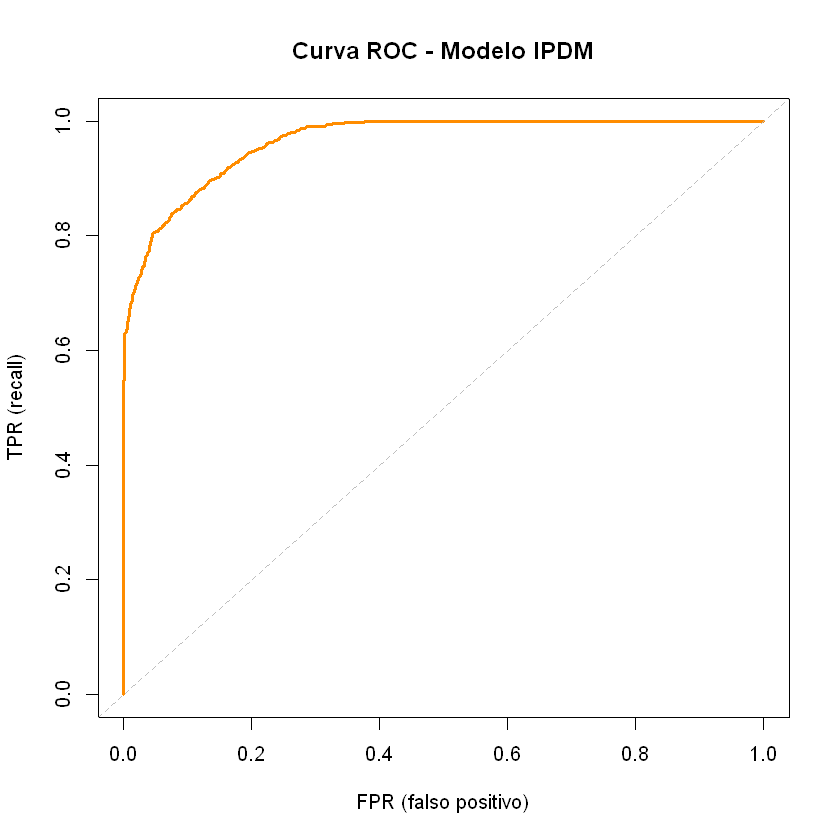

In [5]:
# ============================================================
# REGRESSAO LOGISTICA - ADAPTADO PARA O PROJETO IPDM
# Baseado no script do WhatsApp, ajustado para os dados reais
# ============================================================

# ------------------------------------------------------------
# 1) CARREGAR OS DADOS PROCESSADOS
# ------------------------------------------------------------
# Sobe duas pastas (de scripts/pesquisa_IPDM/ para a raiz) e entra em data/processed/
caminho <- file.path("..", "..", "data", "processed", "Datasets_IPDM", "dados_ipdm_largura.csv")

dados <- read.csv2(caminho, fileEncoding = "latin1")

# Seleciona as colunas que vamos usar:
# - Preditores: as 4 medidas da CIDADE
# - Resposta: a coluna 'media' (0 ou 1)
dados_modelo <- dados[, c("riqueza", "longevidade", "escolaridade", "IPDM", "media")]

# Remove linhas com NA (caso algum municipio nao tenha todas as medidas)
dados_modelo <- na.omit(dados_modelo)

cat("Total de observacoes usadas:", nrow(dados_modelo), "\n")
cat("Proporcao de media = 1:", mean(dados_modelo$media), "\n\n")


# ------------------------------------------------------------
# 2) AJUSTAR O MODELO LOGISTICO
# ------------------------------------------------------------
modelo <- glm(media ~ riqueza + longevidade + escolaridade + IPDM,
              family = binomial,
              data = dados_modelo)

summary(modelo)  # Coeficientes, p-valores, AIC
cat("\nCoeficientes (logit):\n")
print(round(coef(modelo), 4))

# Razao de chances (Odds Ratio)
cat("\nOdds Ratio (exp(coef)):\n")
print(round(exp(coef(modelo)), 4))


# ------------------------------------------------------------
# 3) PREVER PROBABILIDADES PARA TODA A BASE
# ------------------------------------------------------------
p <- predict(modelo, type = "response")   # probabilidade prevista para cada municipio


# ------------------------------------------------------------
# 4) CLASSIFICAR COM LIMIAR 0.5 E MATRIZ DE CONFUSAO
# ------------------------------------------------------------
limiar <- 0.5
yhat <- as.integer(p > limiar)

matriz <- table(Real = dados_modelo$media, Previsto = yhat)
print(matriz)

# Extraindo valores da matriz (cuidado: se faltar uma classe, a tabela pode ter dimensoes diferentes)
if (all(c(0,1) %in% rownames(matriz)) && all(c(0,1) %in% colnames(matriz))) {
  VP <- matriz["1", "1"]
  VN <- matriz["0", "0"]
  FP <- matriz["0", "1"]
  FN <- matriz["1", "0"]

  acuracia       <- (VP + VN) / sum(matriz)
  precisao       <- VP / (VP + FP)
  recall         <- VP / (VP + FN)      # sensibilidade
  especificidade <- VN / (VN + FP)

  cat("\n--- Metricas (limiar = 0.5) ---\n")
  cat("Acuracia:       ", round(acuracia, 3), "\n")
  cat("Precisao:       ", round(precisao, 3), "\n")
  cat("Recall/Sensib:  ", round(recall, 3), "\n")
  cat("Especificidade: ", round(especificidade, 3), "\n")
} else {
  cat("\nATENCAO: Matriz de confusao nao tem todas as classes 0 e 1. Verifique os dados.\n")
}


# ------------------------------------------------------------
# 5) TESTAR DIFERENTES LIMIARES (OPCIONAL)
# ------------------------------------------------------------
testar_limiar <- function(p, y_real, limiar) {
  yhat <- as.integer(p > limiar)
  m <- table(Real = y_real, Previsto = factor(yhat, levels = c(0,1)))
  cat("\n--- Limiar =", limiar, "---\n")
  print(m)
}

testar_limiar(p, dados_modelo$media, 0.3)
testar_limiar(p, dados_modelo$media, 0.5)
testar_limiar(p, dados_modelo$media, 0.7)


# ------------------------------------------------------------
# 6) CURVA ROC E AUC (SEM PACOTES EXTRAS)
# ------------------------------------------------------------
ord <- order(p, decreasing = TRUE)
tpr <- cumsum(dados_modelo$media[ord]) / sum(dados_modelo$media)
fpr <- cumsum(1 - dados_modelo$media[ord]) / sum(1 - dados_modelo$media)

# Plota a ROC
plot(c(0, fpr), c(0, tpr), type = "l", lwd = 3, col = "darkorange",
     xlab = "FPR (falso positivo)", ylab = "TPR (recall)",
     main = "Curva ROC - Modelo IPDM")
abline(0, 1, lty = 2, col = "gray")  # linha do chute aleatorio

# Calcula AUC (probabilidade de o modelo dar p maior para quem tem media=1)
auc <- mean(outer(p[dados_modelo$media == 1], p[dados_modelo$media == 0], ">"))
cat("\nAUC (Area sob a curva):", round(auc, 3), "\n")